In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle(r"C:\Users\adamk\Desktop\Digitální akademie DATA\Projekt\joined_data\cdr_clean_unique_calls_update_num2.pkl")

In [3]:
# Počet unikátních hovorů - spojením "globalCallID_callId", "origLegCallIdentifier" a datumem z "dateTimeOrigination", který je ve formátu 2024-01-01 01:20:13	na 2024-01-01 a 01:20:13	
df['datum'] = df['dateTimeOrigination'].dt.date
df['datum2'] = df['dateTimeOrigination'].dt.time 



In [4]:
#df.sort_values("unique_call_id").head()
df.head()

,globalCallID_callManagerId,globalCallID_callId,origLegCallIdentifier,dateTimeOrigination,callingPartyNumber,origCause_value,destLegIdentifier,originalCalledPartyNumber,finalCalledPartyNumber,destCause_value,...,destCallTerminationOnBehalfOf,origCalledPartyRedirectOnBehalfOf,lastRedirectRedirectOnBehalfOf,origCalledPartyRedirectReason,lastRedirectRedirectReason,joinOnBehalfOf,callSecuredStatus,unique_call_id,datum,datum2
0,1,16615182,19957562,2024-01-01 01:20:13,437734693017,16,19957563,4344124999,4344124999,0,...,0,0,0,0,0,0,0,752520,2024-01-01,01:20:13
1,1,16615183,19957564,2024-01-01 03:08:00,436618449646,16,19957565,433738509500050,433738509500050,0,...,0,0,0,0,0,0,0,752521,2024-01-01,03:08:00
2,1,16615184,19957566,2024-01-01 05:07:47,436359992566,16,19957567,433738509500050,433738509500050,0,...,0,0,0,0,0,0,0,752522,2024-01-01,05:07:47
3,1,16615185,19957568,2024-01-01 05:41:29,9999,16,19957569,4314014190122,4314014190122,0,...,0,0,0,0,0,0,0,752523,2024-01-01,05:41:29
4,1,16615186,19957570,2024-01-01 06:07:14,433496903750,0,19957571,4373935601800,4373935601800,16,...,12,0,0,0,0,0,0,752524,2024-01-01,06:07:14


In [5]:
date_columns=[column for column in df.columns if "date" in column.lower()]
number_columns=[column for column in df.columns if "number" in column.lower()]
print(date_columns)
print(number_columns)

cols=date_columns+number_columns+["unique_call_id"]
cols

['dateTimeOrigination', 'dateTimeConnect', 'dateTimeDisconnect']
['callingPartyNumber', 'originalCalledPartyNumber', 'finalCalledPartyNumber']


['dateTimeOrigination',
 'dateTimeConnect',
 'dateTimeDisconnect',
 'callingPartyNumber',
 'originalCalledPartyNumber',
 'finalCalledPartyNumber',
 'unique_call_id']

In [6]:
df[cols]

,dateTimeOrigination,dateTimeConnect,dateTimeDisconnect,callingPartyNumber,originalCalledPartyNumber,finalCalledPartyNumber,unique_call_id
0,2024-01-01 01:20:13,2024-01-01 01:20:14,2024-01-01 01:20:22,437734693017,4344124999,4344124999,752520
1,2024-01-01 03:08:00,2024-01-01 03:08:02,2024-01-01 03:08:14,436618449646,433738509500050,433738509500050,752521
2,2024-01-01 05:07:47,NaT,2024-01-01 05:07:47,436359992566,433738509500050,433738509500050,752522
3,2024-01-01 05:41:29,2024-01-01 05:41:31,2024-01-01 05:42:05,9999,4314014190122,4314014190122,752523
4,2024-01-01 06:07:14,2024-01-01 06:07:15,2024-01-01 06:07:50,433496903750,4373935601800,4373935601800,752524
...,...,...,...,...,...,...,...
3805581,2024-03-29 19:15:54,2024-03-29 19:15:54,2024-03-29 19:16:39,43204838804831,43204838804829,5058900,2781782
3805582,2024-03-30 15:12:29,2024-03-30 15:12:42,2024-03-30 15:29:03,434005336339264,50335447441930,50335447441930,2781783
3805583,2024-03-30 15:34:07,2024-03-30 15:34:31,2024-03-30 16:06:17,434005336339264,50335447441930,50335447441930,2781784
3805584,2024-03-30 18:13:14,2024-03-30 18:13:31,2024-03-30 18:14:02,432537661412,2868767180,2868767180,2781785


In [7]:
df[df.unique_call_id==0]

,globalCallID_callManagerId,globalCallID_callId,origLegCallIdentifier,dateTimeOrigination,callingPartyNumber,origCause_value,destLegIdentifier,originalCalledPartyNumber,finalCalledPartyNumber,destCause_value,...,destCallTerminationOnBehalfOf,origCalledPartyRedirectOnBehalfOf,lastRedirectRedirectOnBehalfOf,origCalledPartyRedirectReason,lastRedirectRedirectReason,joinOnBehalfOf,callSecuredStatus,unique_call_id,datum,datum2
222972,1,1,20554141,2024-01-16 10:11:47,4369121193063,393216,20554142,4321454093284,4321454093284,393216,...,17,0,0,0,0,0,0,0,2024-01-16,10:11:47
223266,1,1,20554142,2024-01-16 10:11:52,4321454093284,16,20554096,4369121193063,4369121193063,0,...,17,0,18,0,146,18,0,0,2024-01-16,10:11:52


In [8]:
# Z nezmeskanych hovorov vyberieme prvy call (pred prepojenim)
unique_calls_df = df.groupby("unique_call_id").agg({"dateTimeConnect":"min","dateTimeDisconnect":"max"}|{column:"first" for column in df.columns if column not in ["dateTimeConnect","dateTimeDisconnect"]})


In [9]:
unique_calls_df.loc[:,"duration"]=(unique_calls_df.dateTimeDisconnect - unique_calls_df.dateTimeConnect).dt.total_seconds()
unique_calls_df=unique_calls_df[unique_calls_df.duration>0]

C:\Users\adamk\AppData\Local\Temp\ipykernel_14464\3551862209.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 271.   36.   39. ... 1906.   31.   nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  unique_calls_df.loc[:,"duration"]=(unique_calls_df.dateTimeDisconnect - unique_calls_df.dateTimeConnect).dt.total_seconds()


In [10]:
# Top 10 volajících (callingPartyNumber) podle počtu hovorů

top10 = unique_calls_df["callingPartyNumber"].value_counts().head(10)
print(f"Top 10 volajících podle počtu unikátních hovorů: {top10}")

Top 10 volajících podle počtu unikátních hovorů: callingPartyNumber
49237170616      8985
9999             3851
435460889213     3788
432410955211     3408
43434351711      2096
4961378          1943
438660881000     1696
4348751591592    1480
4348751591584    1447
437134539165     1432
Name: count, dtype: int64


In [11]:
# kam nejčastěji volá číslo, které má nejvíce odchozích hovorů
top_caller = "49237170616"
top_caller_calls = df[df['callingPartyNumber'] == top_caller]

top_called = top_caller_calls['finalCalledPartyNumber'].value_counts().head(5)
print(f"Top 5 volaná čísla TOP 1 volajícího ({top_caller})")
print(top_called)

Top 5 volaná čísla TOP 1 volajícího (49237170616)
finalCalledPartyNumber
434204069063942    6015
7230               2799
437493656840         88
7208                 83
Name: count, dtype: int64


In [12]:
# Top 10 volaných (originalCalledPartyNumber) podle počtu hovorů# Zmeskane hovory


top10 = unique_calls_df["originalCalledPartyNumber"].value_counts().head(10)
print(f"Top 10 volaných podle počtu unikátních hovorů: {top10}")

Top 10 volaných podle počtu unikátních hovorů: originalCalledPartyNumber
433738509500050    50570
433738509500150    22559
4389913894000      16963
4373935601800      12536
438451958060       11186
4361566            10530
432410955211        9969
439355329689900     9899
4314014190122       8512
43175606009         7019
Name: count, dtype: int64


In [13]:
# Podíl zabezpečených hovorů (callSecuredStatus) - kolik bylo šifrovaných, kolik nezabezpečených.

non_secured = 0
not_encrypted = 0
encrypted = 0

for status in unique_calls_df['callSecuredStatus']:
    if pd.notna(status):
        if status == 0:
            non_secured += 1
        elif status == 1:
            not_encrypted += 1
        elif status == 2:
            encrypted += 1

total = non_secured + not_encrypted + encrypted

print(f"Non secured: {non_secured}")
print(f"Not encrypted: {not_encrypted}")
print(f"Encrypted: {encrypted}")

Non secured: 1692883
Not encrypted: 2
Encrypted: 3


In [14]:
durations = unique_calls_df['duration']


over_100 = len(durations[durations > 100])
over_1000 = len(durations[durations > 1000])
over_10000 = len(durations[durations > 10000])
over_6h = len(durations[durations > 21600])
over_43000 = len(durations[durations > 43000])

print(f"Hovory delší než 100 s:{over_100}")
print(f"Hovory delší než 1 000 s:{over_1000}")
print(f"Hovory delší než 10 000 s:{over_10000}")
print(f"Hovory delší než 6 hodin:{over_6h}")
print(f"Hovory delší než 43 000 s:{over_43000}")

median_duration = unique_calls_df['duration'].median()
print(f"Medián délky hovoru: {median_duration} sekund")


Hovory delší než 100 s:619591
Hovory delší než 1 000 s:27271
Hovory delší než 10 000 s:119
Hovory delší než 6 hodin:25
Hovory delší než 43 000 s:12
Medián délky hovoru: 60.0 sekund


In [15]:
with pd.option_context('display.max_rows', 5, 'display.max_columns', None): 
    display(df.head(1000))


,globalCallID_callManagerId,globalCallID_callId,origLegCallIdentifier,dateTimeOrigination,callingPartyNumber,origCause_value,destLegIdentifier,originalCalledPartyNumber,finalCalledPartyNumber,destCause_value,dateTimeConnect,dateTimeDisconnect,lastRedirectDn,pkid,duration,origDeviceName,destDeviceName,origCallTerminationOnBehalfOf,destCallTerminationOnBehalfOf,origCalledPartyRedirectOnBehalfOf,lastRedirectRedirectOnBehalfOf,origCalledPartyRedirectReason,lastRedirectRedirectReason,joinOnBehalfOf,callSecuredStatus,unique_call_id,datum,datum2
0,1,16615182,19957562,2024-01-01 01:20:13,437734693017,16,19957563,4344124999,4344124999,0,2024-01-01 01:20:14,2024-01-01 01:20:22,4344124999,126ffab4-584e-42aa-91d5-3d5f66810ccf,8,BK016_000_Tele2,HK010_CC,12,0,0,0,0,0,0,0,752520,2024-01-01,01:20:13
1,1,16615183,19957564,2024-01-01 03:08:00,436618449646,16,19957565,433738509500050,433738509500050,0,2024-01-01 03:08:02,2024-01-01 03:08:14,433738509500050,1c2b2f66-5f99-4994-805f-f01f46e3dbea,12,BK044_023_Tele2,HK010_CC,12,0,0,0,0,0,0,0,752521,2024-01-01,03:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,1,16616083,19960716,2024-01-02 07:21:46,436009976527,16,19960719,4361566,4335165177,0,NaT,2024-01-02 07:21:46,+4361566,b7e76019-73cc-44e2-bf7b-5d228a24843c,0,BK009_000_Tele2,HK010_CC,12,0,5,5,15,15,5,0,753419,2024-01-02,07:21:46
1073,1,16616050,19960582,2024-01-02 07:20:09,435094408421,16,19960584,8985999,8985998,0,2024-01-02 07:20:09,2024-01-02 07:21:51,8985999,6cb91188-db55-4cf6-a9ed-1968e7dc8557,102,BK125_000_Tele2,Unity_Connection_Publisher,12,0,1,1,18,18,1,0,753386,2024-01-02,07:20:09


In [16]:
# Kolik hovorů v lednu, únoru a březnu
hovory_leden = 0
hovory_unor = 0
hovory_brezen = 0

# projít všechny hovory
for date in unique_calls_df['dateTimeConnect']:
    if pd.notna(date):  
        if pd.Timestamp('2024-01-01') <= date <= pd.Timestamp('2024-01-31 23:59:59'):
            hovory_leden += 1
        elif pd.Timestamp('2024-02-01') <= date <= pd.Timestamp('2024-02-29 23:59:59'):
            hovory_unor += 1
        elif pd.Timestamp('2024-03-01') <= date <= pd.Timestamp('2024-03-31 23:59:59'):
            hovory_brezen += 1

print(f"Hovory v lednu: {hovory_leden}")
print(f"Hovory v únoru: {hovory_unor}")
print(f"Hovory v březnu: {hovory_brezen}")

Hovory v lednu: 613804
Hovory v únoru: 551577
Hovory v březnu: 527507


In [17]:
unique_calls_df[['dateTimeOrigination', 'dateTimeConnect', 'dateTimeDisconnect']].head(10)


,dateTimeOrigination,dateTimeConnect,dateTimeDisconnect
unique_call_id,,,
0,2024-01-16 10:11:47,2024-01-16 10:11:52,2024-01-16 10:16:23
1,2024-01-16 10:11:49,2024-01-16 10:11:49,2024-01-16 10:12:25
2,2024-01-16 10:11:49,2024-01-16 10:11:50,2024-01-16 10:12:29
4,2024-01-16 10:11:51,2024-01-16 10:11:51,2024-01-16 10:17:31
8,2024-01-16 10:11:53,2024-01-16 10:11:53,2024-01-16 10:12:32
9,2024-01-16 10:11:56,2024-01-16 10:11:57,2024-01-16 10:12:24
10,2024-01-16 10:11:59,2024-01-16 10:12:06,2024-01-16 10:12:41
11,2024-01-16 10:12:01,2024-01-16 10:12:02,2024-01-16 10:12:10
13,2024-01-16 10:12:01,2024-01-16 10:12:03,2024-01-16 10:12:43


Počet hovorů podle dnů v týdnu:
Po: 351343
Út: 350698
St: 349703
Čt: 347347
Pá: 288858
So: 3223
Ne: 1716


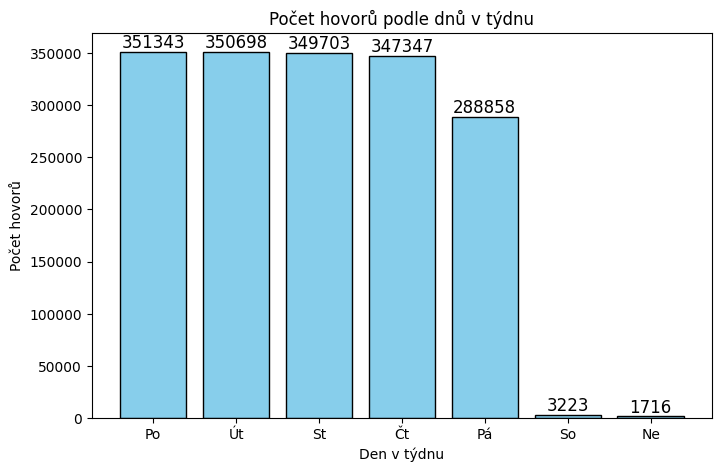

In [18]:
# Počet hovorů rozdělených na dny (Po - Ne) za poslední čtvrtletí
dni = {'Po':0, 'Út':0, 'St':0, 'Čt':0, 'Pá':0, 'So':0, 'Ne':0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        den = date.weekday()  # pondělí=0, neděle=6
        if den == 0:
            dni['Po'] += 1 
        elif den == 1:
            dni['Út'] += 1
        elif den == 2:
            dni['St'] += 1
        elif den == 3:
            dni['Čt'] += 1
        elif den == 4:
            dni['Pá'] += 1
        elif den == 5:
            dni['So'] += 1
        elif den == 6:
            dni['Ne'] += 1

print("Počet hovorů podle dnů v týdnu:")
for den, pocet in dni.items():
    print(f"{den}: {pocet}")

nazvy_dnu = list(dni.keys())
pocet_hovoru = list(dni.values())


plt.figure(figsize=(8,5))
bars = plt.bar(nazvy_dnu, pocet_hovoru, color='skyblue', edgecolor='black')
plt.title('Počet hovorů podle dnů v týdnu')
plt.xlabel('Den v týdnu')
plt.ylabel('Počet hovorů')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)
plt.show()

Počet hovorů podle časových bloků:
6-12: 1129226
12-18: 557656
18-24: 4173
0-6: 1833


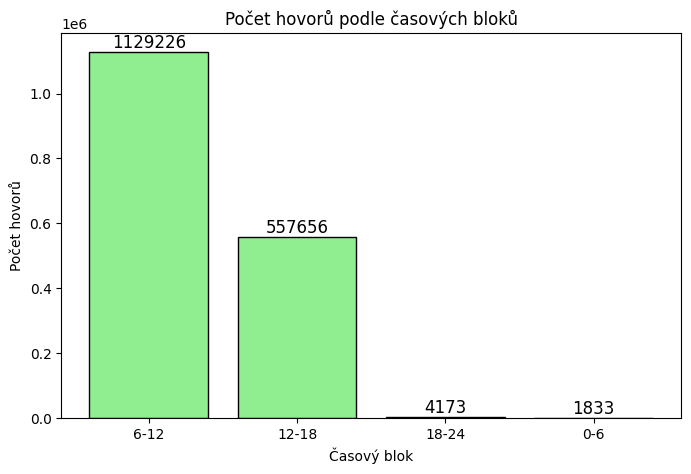

In [19]:
# Kdy se nejčastěji volá dle jednotlivých dnů 6-12, 12-18, 18-24 a 24-6
casove_bloky = {'6-12':0, '12-18':0, '18-24':0, '0-6':0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        hodina = date.hour
        if 6 <= hodina < 12:
            casove_bloky['6-12'] += 1
        elif 12 <= hodina < 18:
            casove_bloky['12-18'] += 1
        elif 18 <= hodina < 24:
            casove_bloky['18-24'] += 1
        else:  # 0-6
            casove_bloky['0-6'] += 1

print("Počet hovorů podle časových bloků:")
for blok, pocet in casove_bloky.items():
    print(f"{blok}: {pocet}")

nazvy_bloku = list(casove_bloky.keys())
pocet_hovoru = list(casove_bloky.values())

plt.figure(figsize=(8,5))
bars = plt.bar(nazvy_bloku, pocet_hovoru, color='lightgreen', edgecolor='black')
plt.title('Počet hovorů podle časových bloků')
plt.xlabel('Časový blok')
plt.ylabel('Počet hovorů')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)
plt.show()

Distribuce hovorů v bloku 6-12 po hodinách:
4:00 - 97 hovorů
5:00 - 687 hovorů
6:00 - 23645 hovorů
7:00 - 203278 hovorů
8:00 - 265141 hovorů
9:00 - 265144 hovorů
10:00 - 252123 hovorů
11:00 - 119895 hovorů
12:00 - 136052 hovorů
13:00 - 172644 hovorů
14:00 - 149981 hovorů
15:00 - 77678 hovorů
16:00 - 17149 hovorů
17:00 - 4152 hovorů
18:00 - 1533 hovorů
19:00 - 792 hovorů
20:00 - 0 hovorů


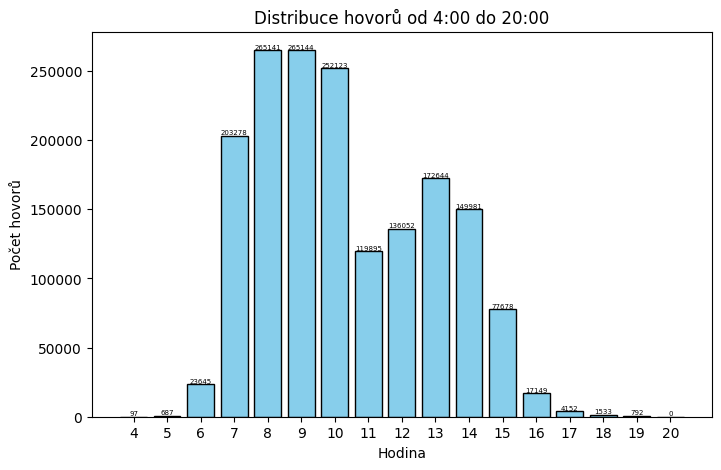

In [20]:
blok_4_20 = {4:0, 5:0, 6:0, 7:0, 8:0, 9:0, 10:0, 11:0, 12:0, 13:0, 14:0, 15:0, 16:0, 17:0, 18:0, 19:0, 20:0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        hodina = date.hour
        if 4 <= hodina < 20:
            blok_4_20[hodina] += 1


print("Distribuce hovorů v bloku 6-12 po hodinách:")
for hod, pocet in blok_4_20.items():
    print(f"{hod}:00 - {pocet} hovorů")


hodiny = list(blok_4_20.keys())
pocet_hovoru = list(blok_4_20.values())

plt.figure(figsize=(8,5))
bars = plt.bar(hodiny, pocet_hovoru, color='skyblue', edgecolor='black')
plt.title('Distribuce hovorů od 4:00 do 20:00')
plt.xlabel('Hodina')
plt.ylabel('Počet hovorů')
plt.xticks(hodiny) 
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=5)
plt.show()